# Employee Retention Prediction

Machine Learning project to predict whether a data scientist is likely to look for a job change.


## Business Problem

Companies invest significant resources in hiring and training employees.
Predicting which employees are likely to leave can help organizations:

- Improve employee retention
- Reduce hiring costs
- Plan workforce requirements
- Design targeted retention strategies

In [4]:
# =========================
# 1. Imports
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib


## Dataset Description

The dataset contains information about employees such as:

- Gender
- Education Level
- Relevant Experience
- Company Size
- Company Type
- Training Hours
- City Development Index

### Target Variable

- 0 = Not looking for a job change
- 1 = Looking for a job change

In [5]:
# =========================
# 2. Load train & test data
# =========================

train_path = "../data/aug_train.csv"
test_path = "../data/aug_test.csv"

train = pd.read_csv(r"C:\Users\vimal.HARSH\OneDrive\Desktop\Employee Retention Prediction\aug_train.csv")
test = pd.read_csv(r"C:\Users\vimal.HARSH\OneDrive\Desktop\Employee Retention Prediction\aug_test.csv")

# Quick look at the data
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (19158, 14)
Test shape: (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


### Missing Values Analysis

This section identifies columns with missing values and helps determine appropriate imputation strategies.

In [6]:
# Check missing values per column
train.isna().sum().sort_values(ascending=False)


company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
enrollee_id                  0
city                         0
city_development_index       0
relevent_experience          0
training_hours               0
target                       0
dtype: int64

## Exploratory Data Analysis

EDA helps understand:

- Class distribution
- Missing values
- Feature distributions
- Relationships between variables
- Potential data quality issues

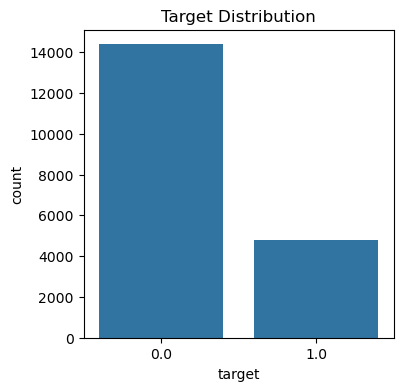

In [4]:
# Plot target distribution
plt.figure(figsize=(4, 4))
sns.countplot(x='target', data=train)
plt.title("Target Distribution")
plt.show()


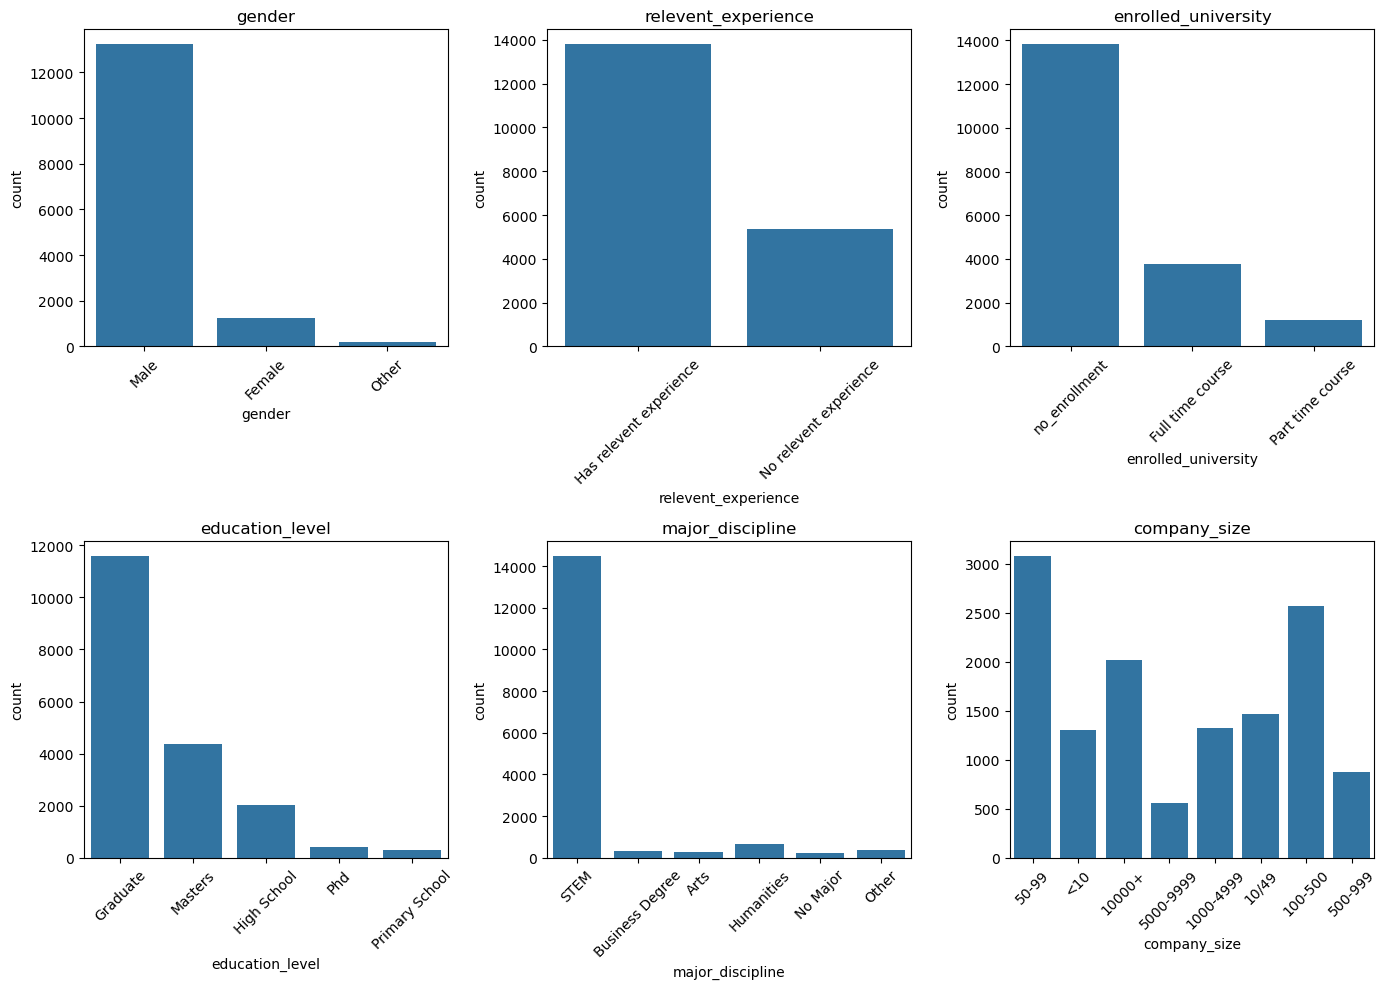

In [5]:
# Univariate plots for some categorical features
categorical_cols = [
    'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'major_discipline', 'company_size',
    'company_type', 'last_new_job', 'experience'
]

plt.figure(figsize=(14, 10))
for i, col in enumerate(categorical_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=train)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()


### Categorical Feature Analysis

We analyze the impact of categorical features on employee job-change behavior.

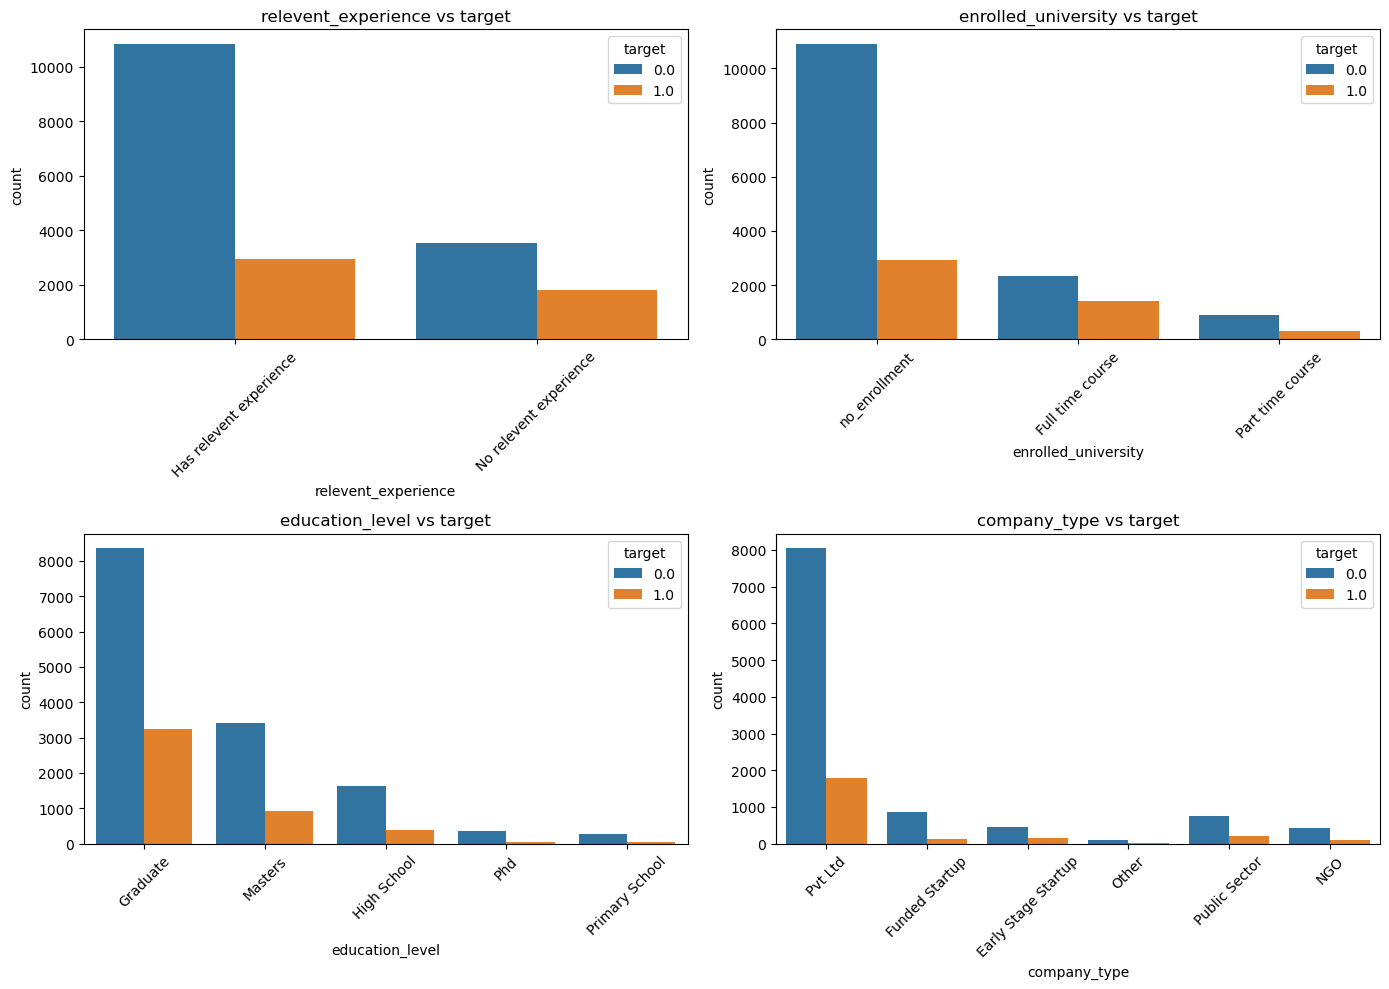

In [6]:
# Relationship between some categorical features and target
plt.figure(figsize=(14, 10))
for i, col in enumerate(['relevent_experience', 'enrolled_university', 'education_level', 'company_type'], 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='target', data=train)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs target")
plt.tight_layout()
plt.show()


### Numerical Feature Analysis

Understanding the distribution of numerical variables such as:

- City Development Index
- Training Hours

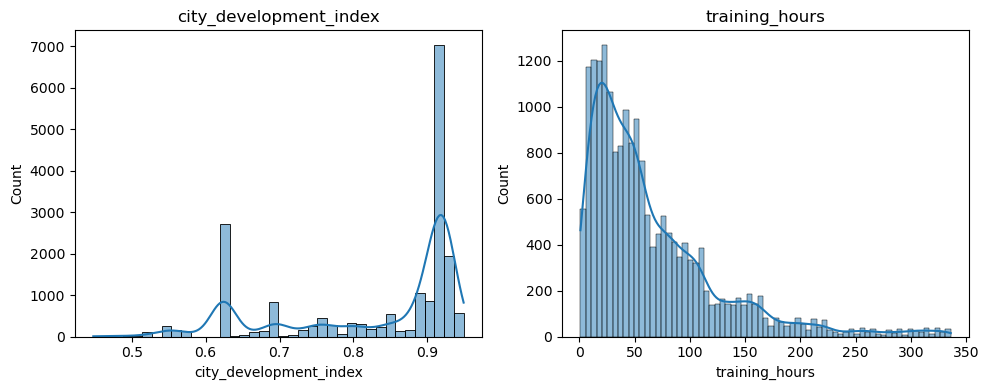

In [7]:
# Numerical features distribution
num_cols = ['city_development_index', 'training_hours']

plt.figure(figsize=(10, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(train[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


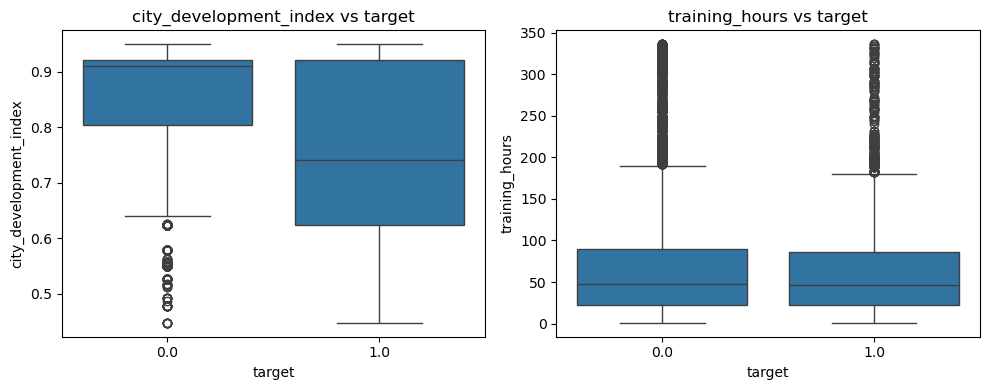

In [8]:
# Boxplots of numerical features vs target
plt.figure(figsize=(10, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x='target', y=col, data=train)
    plt.title(f"{col} vs target")
plt.tight_layout()
plt.show()


## Data Preprocessing

The preprocessing pipeline includes:

- Missing value imputation
- Feature scaling
- One-Hot Encoding
- Handling class imbalance using SMOTE

In [9]:
# =========================
# 4. Preprocessing setup
# =========================

# Drop ID and target for feature matrix
X = train.drop(columns=['enrollee_id', 'target'])
y = train['target']

# Identify column types
numeric_features = ['city_development_index', 'training_hours']
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['city_development_index', 'training_hours']
Categorical features: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


In [10]:
# ColumnTransformer for preprocessing
numeric_transformer = Pipeline(steps=[
    # Fill missing numeric values with median, then scale
    ('imputer',  __import__('sklearn').impute.SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # Fill missing categorical values with 'Unknown', then one-hot encode
    ('imputer', __import__('sklearn').impute.SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Train Validation Split

The dataset is divided into training and validation sets to evaluate model generalization performance.

In [11]:
# =========================
# 5. Train-validation split
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape, "Validation size:", X_val.shape)


Train size: (15326, 12) Validation size: (3832, 12)


In [12]:
# Check class imbalance
print("Train class distribution:")
print(y_train.value_counts())
print("\nValidation class distribution:")
print(y_val.value_counts())


Train class distribution:
target
0.0    11504
1.0     3822
Name: count, dtype: int64

Validation class distribution:
target
0.0    2877
1.0     955
Name: count, dtype: int64


### Evaluation Metrics

Models are evaluated using:

- Accuracy
- ROC-AUC Score
- Classification Report
- Confusion Matrix

In [13]:
# =========================
# 6. Helper: train & evaluate
# =========================

def evaluate_model(name, model):
    """
    Fit model on training data (with SMOTE) and evaluate on validation data.
    Prints metrics and returns fitted pipeline and metrics.
    """
    # Build pipeline: preprocessing + SMOTE + classifier
    clf = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    
    # Fit
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    roc = roc_auc_score(y_val, y_proba)
    cm = confusion_matrix(y_val, y_pred)
    
    print(f"\n==================== {name} ====================")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    
    # ROC curve
    RocCurveDisplay.from_predictions(y_val, y_proba)
    plt.title(f"ROC Curve - {name}")
    plt.show()
    
    return clf, acc, roc


## Model Training

The following machine learning models are trained and compared:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM


==================== Logistic Regression ====================
Accuracy: 0.7489561586638831
ROC-AUC: 0.7904674553736348
Confusion Matrix:
 [[2150  727]
 [ 235  720]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.75      0.82      2877
         1.0       0.50      0.75      0.60       955

    accuracy                           0.75      3832
   macro avg       0.70      0.75      0.71      3832
weighted avg       0.80      0.75      0.76      3832



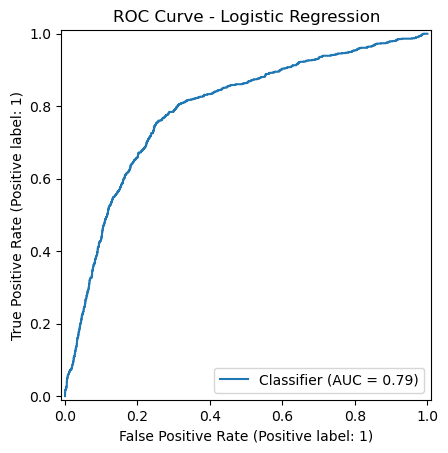

In [14]:
# Logistic Regression
log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,  # SMOTE already balances classes
    n_jobs=-1
)

log_reg_clf, log_reg_acc, log_reg_roc = evaluate_model("Logistic Regression", log_reg_model)



==================== Random Forest ====================
Accuracy: 0.7674843423799582
ROC-AUC: 0.7807028845856376
Confusion Matrix:
 [[2500  377]
 [ 514  441]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.87      0.85      2877
         1.0       0.54      0.46      0.50       955

    accuracy                           0.77      3832
   macro avg       0.68      0.67      0.67      3832
weighted avg       0.76      0.77      0.76      3832



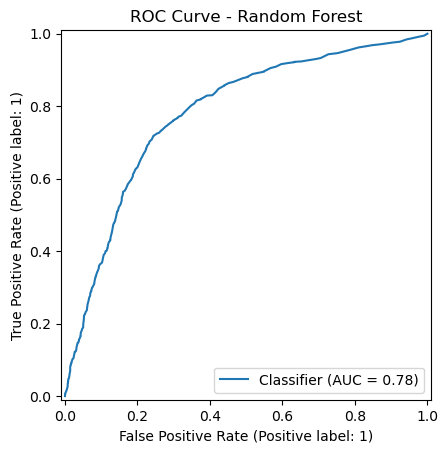

In [15]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_clf, rf_acc, rf_roc = evaluate_model("Random Forest", rf_model)



==================== XGBoost ====================
Accuracy: 0.7894050104384134
ROC-AUC: 0.7992316749377169
Confusion Matrix:
 [[2499  378]
 [ 429  526]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.87      0.86      2877
         1.0       0.58      0.55      0.57       955

    accuracy                           0.79      3832
   macro avg       0.72      0.71      0.71      3832
weighted avg       0.79      0.79      0.79      3832



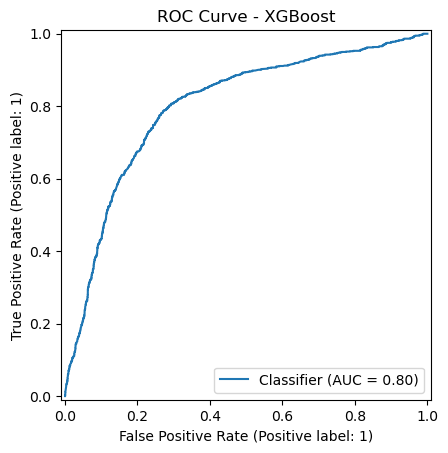

In [16]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_clf, xgb_acc, xgb_roc = evaluate_model("XGBoost", xgb_model)


[LightGBM] [Info] Number of positive: 11504, number of negative: 11504
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12508
[LightGBM] [Info] Number of data points in the train set: 23008, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

==================== LightGBM ====================
Accuracy: 0.7779227557411273
ROC-AUC: 0.8000442214566875
Confusion Matrix:
 [[2427  450]
 [ 401  554]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      2877
         1.0       0.55      0.58      0.57       955

    accuracy                           0.78      3832
   macro avg       0.70      0.71      0.71      3832
weighted avg       0.78      0.78      0.78

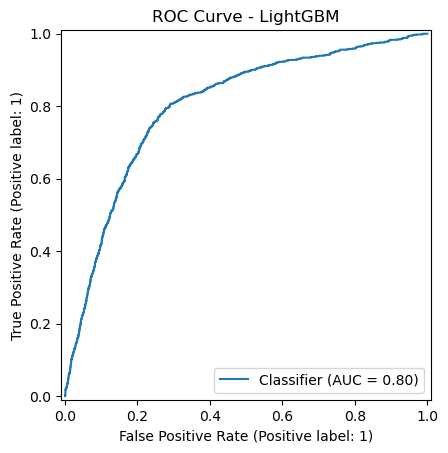

In [17]:
# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_clf, lgbm_acc, lgbm_roc = evaluate_model("LightGBM", lgbm_model)


## Model Comparison

Performance of all models is compared to identify the best-performing model.

In [18]:
# =========================
# 7. Model comparison
# =========================

results = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'accuracy': [log_reg_acc, rf_acc, xgb_acc, lgbm_acc],
    'roc_auc': [log_reg_roc, rf_roc, xgb_roc, lgbm_roc]
})

results.sort_values(by='roc_auc', ascending=False)


,model,accuracy,roc_auc
3,LightGBM,0.777923,0.800044
2,XGBoost,0.789405,0.799232
0,Logistic Regression,0.748956,0.790467
1,Random Forest,0.767484,0.780703


## Feature Importance

Feature importance helps identify which factors most influence employee retention and job-change decisions.

In [19]:
# =========================
# 8. Feature importance (Random Forest)
# =========================

# Get feature names after preprocessing
# This is a bit involved because of ColumnTransformer + OneHotEncoder

# Fit a simple pipeline without SMOTE just to extract feature names
simple_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

simple_rf_pipeline.fit(X_train, y_train)

# Get transformed feature names
# Numeric features stay as is; categorical become one-hot columns
ohe = simple_rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([numeric_features, cat_feature_names])

# Get feature importances from RF
importances = simple_rf_pipeline.named_steps['model'].feature_importances_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

fi.head(20)


,feature,importance
1,training_hours,0.217536
0,city_development_index,0.099005
65,city_city_21,0.052491
169,company_size_50-99,0.026986
179,last_new_job_1,0.020433
132,education_level_Graduate,0.016122
180,last_new_job_2,0.015076
129,enrolled_university_Full time course,0.013414
131,enrolled_university_no_enrollment,0.013353
164,experience_>20,0.012075


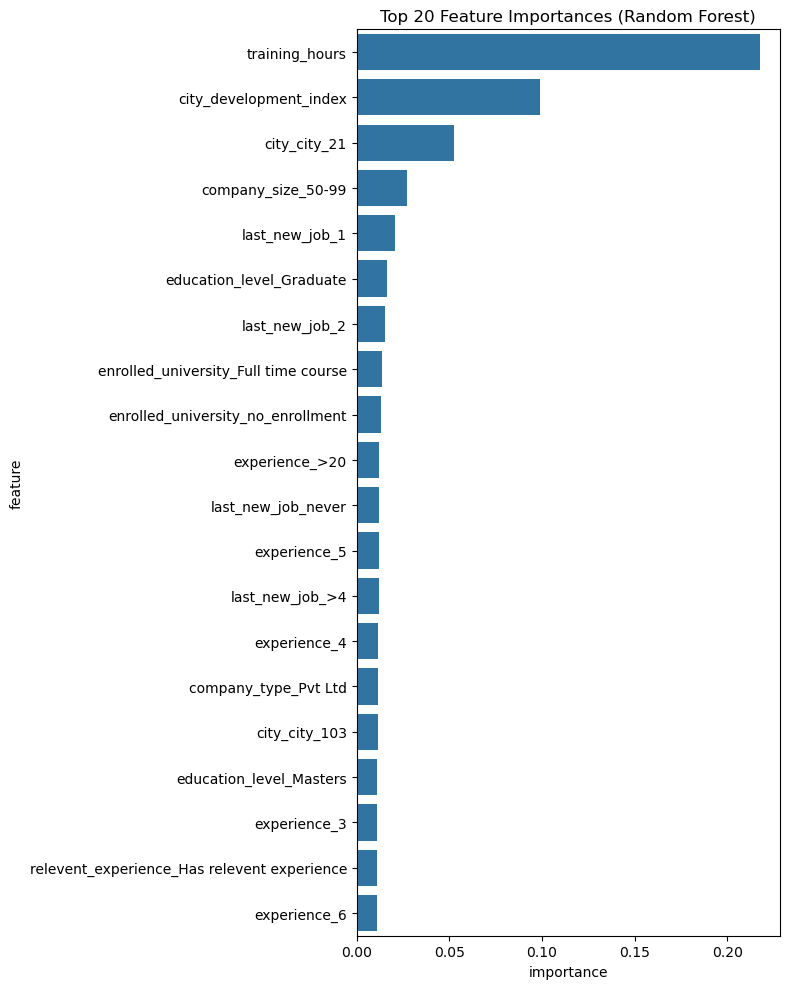

In [20]:
# Plot top 20 important features
plt.figure(figsize=(8, 10))
sns.barplot(x='importance', y='feature', data=fi.head(20))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


## Final Model

Based on validation performance, the best model is selected and retrained on the full dataset.

In [21]:
# =========================
# 9. Final model on full data
# =========================

# Recreate X, y from full train
X_full = train.drop(columns=['enrollee_id', 'target'])
y_full = train['target']

# Choose best model (example: LightGBM)
best_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

final_clf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', best_model)
])

final_clf.fit(X_full, y_full)


[LightGBM] [Info] Number of positive: 14381, number of negative: 14381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13789
[LightGBM] [Info] Number of data points in the train set: 28762, number of used features: 159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Test Set Predictions

Generate predictions and probability scores for unseen employees.

In [22]:
# =========================
# 10. Predict on test data
# =========================

X_test = test.drop(columns=['enrollee_id'])

test_pred = final_clf.predict(X_test)
test_proba = final_clf.predict_proba(X_test)[:, 1]  # if you want probabilities

submission = pd.DataFrame({
    'enrollee_id': test['enrollee_id'],
    'target': test_pred
})

submission.head()


,enrollee_id,target
0,32403,0.0
1,9858,0.0
2,31806,1.0
3,27385,0.0
4,27724,0.0


In [27]:
import os
os.getcwd()


'C:\\Users\\vimal.HARSH'

In [28]:
os.makedirs("models", exist_ok=True)


In [29]:
submission.to_csv("models/test_predictions.csv", index=False)
joblib.dump(final_clf, "models/best_model_lgbm.pkl")


['models/best_model_lgbm.pkl']

## Model Persistence

The trained model is saved for future inference and deployment.

In [30]:
import os

# Create folder inside your project directory
os.makedirs("models", exist_ok=True)

submission.to_csv("models/test_predictions.csv", index=False)
joblib.dump(final_clf, "models/best_model_lgbm.pkl")

print("Saved successfully!")


Saved successfully!


In [31]:
%%writefile app.py
# This file will be overwritten with your Streamlit code
print("app.py created successfully!")


Writing app.py


## Streamlit Deployment

A Streamlit application is created to allow users to:

- Upload employee data
- Generate predictions
- View prediction probabilities
- Download results

In [32]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline (preprocessor + SMOTE + LightGBM)
model = joblib.load("models/best_model_lgbm.pkl")

st.set_page_config(page_title="Employee Job Change Prediction", layout="wide")

st.title("🔮 Employee Job Change Prediction App")
st.write("Predict whether a data scientist is likely to look for a job change.")

# -----------------------------
# Input Form
# -----------------------------
st.header("Enter Employee Details")

col1, col2 = st.columns(2)

with col1:
    city = st.text_input("City (e.g., city_41)")
    city_development_index = st.number_input("City Development Index", min_value=0.0, max_value=1.0, step=0.01)
    gender = st.selectbox("Gender", ["Male", "Female", "Other", "Unknown"])
    relevent_experience = st.selectbox("Relevant Experience", ["Has relevent experience", "No relevent experience"])

with col2:
    enrolled_university = st.selectbox("Enrolled University", ["no_enrollment", "Full time course", "Part time course"])
    education_level = st.selectbox("Education Level", ["Graduate", "Masters", "Phd", "High School", "Primary School"])
    major_discipline = st.selectbox("Major Discipline", ["STEM", "Business Degree", "Arts", "Humanities", "Other", "Unknown"])
    experience = st.selectbox("Experience", ["<1", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", ">20"])

company_size = st.selectbox("Company Size", ["<10", "10-49", "50-99", "100-500", "500-999", "1000-4999", "5000-9999", "10000+", "Unknown"])
company_type = st.selectbox("Company Type", ["Pvt Ltd", "Funded Startup", "Early Stage Startup", "Public Sector", "NGO", "Other", "Unknown"])
last_new_job = st.selectbox("Last New Job", ["never", "1", "2", "3", "4", ">4"])
training_hours = st.number_input("Training Hours", min_value=0, max_value=500, step=1)

# -----------------------------
# Prediction
# -----------------------------
if st.button("Predict Job Change Probability"):
    
    # Create a single-row DataFrame
    input_data = pd.DataFrame({
        "city": [city],
        "city_development_index": [city_development_index],
        "gender": [gender],
        "relevent_experience": [relevent_experience],
        "enrolled_university": [enrolled_university],
        "education_level": [education_level],
        "major_discipline": [major_discipline],
        "experience": [experience],
        "company_size": [company_size],
        "company_type": [company_type],
        "last_new_job": [last_new_job],
        "training_hours": [training_hours]
    })

    # Predict
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.subheader("📊 Prediction Result")
    st.write(f"**Probability of Job Change:** {probability:.2f}")

    if prediction == 1:
        st.error("⚠️ The employee is likely to look for a job change.")
    else:
        st.success("✅ The employee is unlikely to look for a job change.")

    st.write("This prediction is based on your trained LightGBM model.")


Overwriting app.py


In [ ]:
!streamlit run app.py


## Conclusion

This project successfully predicts employee job-change behavior using machine learning.

### Key Achievements

- Performed complete EDA
- Built preprocessing pipeline
- Handled class imbalance with SMOTE
- Compared multiple ML models
- Selected the best-performing model
- Deployed the solution using Streamlit